# 🌾 Crop Recommendation — Model Selection
**Task :** Multi-class classification — predict `Crop` from State, District, Season, Year  
**Data :** `crop_train.csv` / `crop_test.csv` (processed)  
**Notebook :** `04_crop_model_selection.ipynb`

### Strategy
| Step | Detail |
|------|--------|
| Encoding | `OrdinalEncoder` for categorical features (fast, tree-compatible) |
| Selection | 5-fold stratified CV on **train set** → compare Accuracy & weighted-F1 |
| Models | Logistic Regression · Decision Tree · Random Forest · Extra Trees · Gradient Boosting · XGBoost · LightGBM |
| Final eval | Best model evaluated on held-out **test set** |
| Output | `crop_best_model_info.txt` written to `../outputs/` |

## 1. Imports & Setup

In [17]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    top_k_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)

# Classifiers
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier
)
try:
    from xgboost  import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  xgboost not installed — skipping')

try:
    from lightgbm import LGBMClassifier
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print('⚠️  lightgbm not installed — skipping')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#333355',   'axes.labelcolor': '#e0e0f0',
    'text.color': '#e0e0f0',       'xtick.color': '#a0a0c0',
    'ytick.color': '#a0a0c0',      'grid.color': '#2a2a4a',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'font.size': 11,
})
ACCENT = '#7c3aed'; ACCENT2 = '#06b6d4'; HIGHLIGHT = '#f59e0b'
RANDOM_STATE = 42
print('Setup complete')

Setup complete


## 2. Load Data

In [ ]:
train = pd.read_csv('../data/processed/crop_train.csv')
test  = pd.read_csv('../data/processed/crop_test.csv')

print(f'Train : {train.shape}   Test : {test.shape}')
print(f'Columns: {list(train.columns)}')
print(f'Unique Crops_Category: {train["Crop_Category"].nunique()}')

train.head()

Train : (276261, 5)   Test : (69066, 5)
Columns: ['State', 'District', 'Season', 'Year', 'Crop_Category']
Unique crops_Category: 9


,State,District,Season,Year,Crop_Category
0,Uttar Pradesh,Faizabad,Rabi,2000,Cereals
1,Maharashtra,Akola,Kharif,2014,Pulses
2,Uttar Pradesh,Fatehpur,Summer,2014,Pulses
3,Haryana,Gurgaon,Whole Year,2006,Vegetables
4,Karnataka,Koppal,Summer,1999,Cereals


## 3. Feature Engineering & Encoding

In [20]:
CAT_FEATURES = ['State', 'District', 'Season']
NUM_FEATURES = ['Year']
FEATURES     = CAT_FEATURES + NUM_FEATURES
TARGET       = 'Crop_Category'

# --- Ordinal-encode categorical features (unknown categories → -1)
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(train[CAT_FEATURES])

def prepare_X_y(df, encoder, fit=False):
    X_cat = encoder.transform(df[CAT_FEATURES])
    X_num = df[NUM_FEATURES].values
    X     = np.hstack([X_cat, X_num])
    y     = df[TARGET].values
    return X, y

X_train, y_train = prepare_X_y(train, enc)
X_test,  y_test  = prepare_X_y(test,  enc)

# Encode target labels for XGBoost compatibility
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'Classes : {len(le.classes_)}')

X_train : (276261, 4)   X_test : (69066, 4)
Classes : 9


## 4. Define Candidate Models

In [21]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, solver='saga', n_jobs=-1, random_state=RANDOM_STATE),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=20, min_samples_leaf=10, random_state=RANDOM_STATE),

    'Random Forest': RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=500, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        random_state=RANDOM_STATE),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
        eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE,
        verbosity=0)

if LGB_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=-1,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)

print(f'Models to evaluate: {list(models.keys())}')

Models to evaluate: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost', 'LightGBM']


## 5. Cross-Validation Model Comparison

In [23]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'}

results = {}

for name, model in models.items():
    print(f'▶  {name} ...', end=' ', flush=True)
    t0 = time.time()

    # XGBoost needs integer-encoded labels
    y_cv = y_train_enc if 'XGB' in name or 'XGBoost' in name else y_train

    cv_out = cross_validate(
        model, X_train, y_cv, cv=CV, scoring=SCORING,
        return_train_score=True, n_jobs=1)

    elapsed = time.time() - t0
    results[name] = {
        'cv_acc_mean'   : cv_out['test_accuracy'].mean(),
        'cv_acc_std'    : cv_out['test_accuracy'].std(),
        'cv_f1_mean'    : cv_out['test_f1_weighted'].mean(),
        'cv_f1_std'     : cv_out['test_f1_weighted'].std(),
        'train_acc_mean': cv_out['train_accuracy'].mean(),
        'train_f1_mean' : cv_out['train_f1_weighted'].mean(),
        'fit_time_s'    : elapsed,
    }
    print(f'acc={results[name]["cv_acc_mean"]:.4f}  f1={results[name]["cv_f1_mean"]:.4f}  ({elapsed:.1f}s)')

print('\n CV complete')

▶  Logistic Regression ... acc=0.3241  f1=0.2335  (1001.3s)
▶  Decision Tree ... acc=0.3142  f1=0.2969  (18.1s)
▶  Random Forest ... acc=0.2867  f1=0.2706  (176.8s)
▶  Extra Trees ... acc=0.2906  f1=0.2715  (140.5s)
▶  Gradient Boosting ... 

KeyboardInterrupt: 

## 6. Results Table

In [7]:
res_df = pd.DataFrame(results).T.sort_values('cv_acc_mean', ascending=False)
res_df.columns = ['CV Acc', 'CV Acc Std', 'CV F1', 'CV F1 Std',
                  'Train Acc', 'Train F1', 'Time (s)']

# Overfit indicator
res_df['Overfit Gap'] = (res_df['Train Acc'] - res_df['CV Acc']).round(4)

pd.set_option('display.float_format', '{:.4f}'.format)
res_df

,CV Acc,CV Acc Std,CV F1,CV F1 Std,Train Acc,Train F1,Time (s),Overfit Gap
Gradient Boosting,0.1032,0.0012,0.0923,0.0013,0.1454,0.1346,6944.5322,0.0421
XGBoost,0.0930,0.0009,0.0820,0.0008,0.1533,0.1419,714.5758,0.0604
Logistic Regression,0.0804,0.0007,0.0221,0.0003,0.0805,0.0221,1570.1240,0.0000
Decision Tree,0.0440,0.0015,0.0486,0.0018,0.1802,0.1669,19.6120,0.1362
LightGBM,0.0405,0.0139,0.0310,0.0202,0.0887,0.0771,1254.8158,0.0482
Extra Trees,0.0243,0.0004,0.0194,0.0004,0.1940,0.1734,116.9316,0.1697
Random Forest,0.0226,0.0007,0.0211,0.0006,0.1943,0.1907,142.1901,0.1716


## 7. Visualise CV Scores

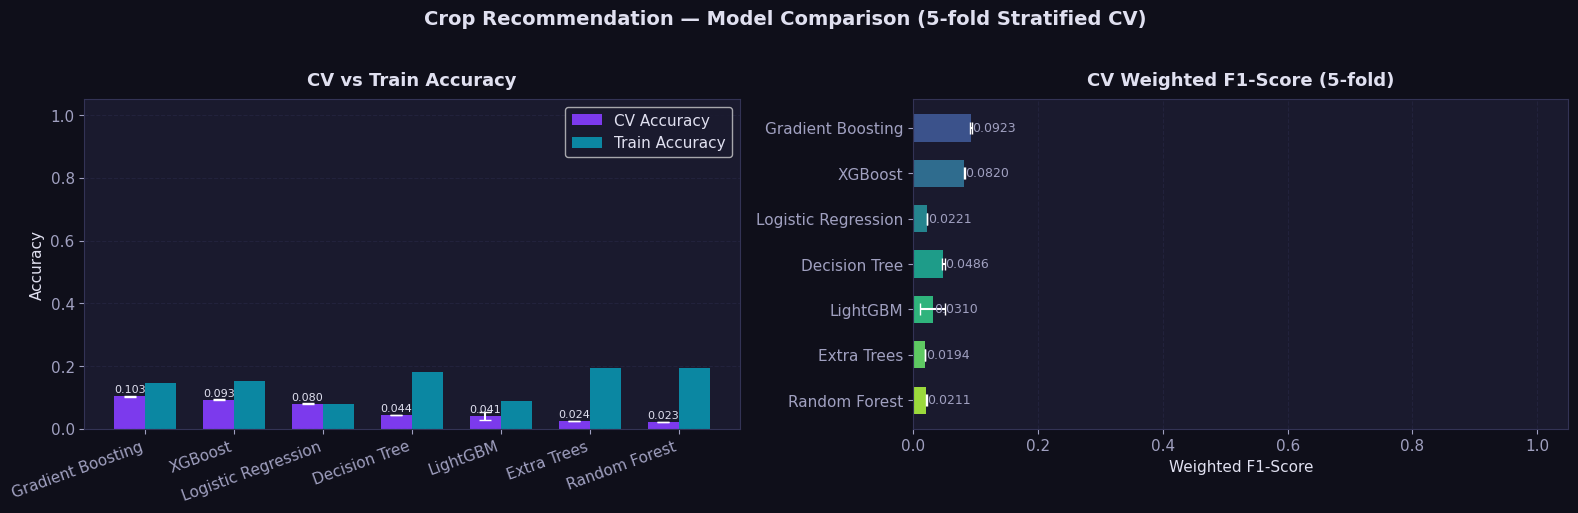

In [8]:
model_names = res_df.index.tolist()
acc_vals    = res_df['CV Acc'].values
acc_stds    = res_df['CV Acc Std'].values
f1_vals     = res_df['CV F1'].values
x           = np.arange(len(model_names))
w           = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy
bar1 = axes[0].bar(x - w/2, acc_vals, w, color=ACCENT,  edgecolor='none', label='CV Accuracy')
bar2 = axes[0].bar(x + w/2, res_df['Train Acc'].values, w, color=ACCENT2, edgecolor='none', label='Train Accuracy', alpha=0.7)
axes[0].errorbar(x - w/2, acc_vals, yerr=acc_stds, fmt='none', color='white', capsize=4, linewidth=1.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=20, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CV vs Train Accuracy', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis='y')
for bar in bar1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                 ha='center', va='bottom', fontsize=8, color='#e0e0f0')

# F1
colors_f1 = plt.cm.viridis(np.linspace(0.85, 0.25, len(model_names)))
axes[1].barh(model_names[::-1], f1_vals[::-1], color=colors_f1, edgecolor='none', height=0.6)
axes[1].errorbar(f1_vals[::-1], model_names[::-1], xerr=res_df['CV F1 Std'].values[::-1],
                 fmt='none', color='white', capsize=4, linewidth=1.5)
for i, (name, val) in enumerate(zip(model_names[::-1], f1_vals[::-1])):
    axes[1].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9, color='#a0a0c0')
axes[1].set_xlabel('Weighted F1-Score')
axes[1].set_title('CV Weighted F1-Score (5-fold)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis='x')

fig.suptitle('Crop Recommendation — Model Comparison (5-fold Stratified CV)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

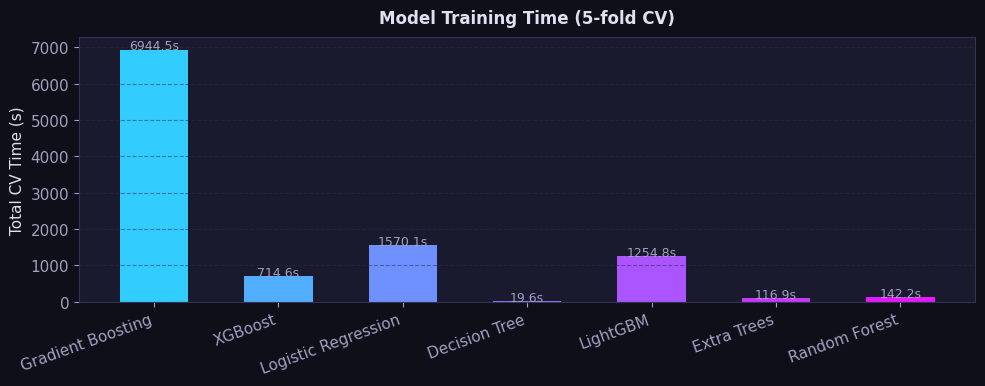

In [9]:
# Training time comparison
times = res_df['Time (s)'].values
fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = plt.cm.cool(np.linspace(0.2, 0.9, len(model_names)))
ax.bar(res_df.index, times, color=bar_colors, edgecolor='none', width=0.55)
for i, v in enumerate(times):
    ax.text(i, v + 0.5, f'{v:.1f}s', ha='center', fontsize=9, color='#a0a0c0')
ax.set_ylabel('Total CV Time (s)')
ax.set_title('Model Training Time (5-fold CV)', fontsize=12, fontweight='bold', pad=10)
ax.set_xticklabels(res_df.index, rotation=20, ha='right')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## 8. Select Best Model & Train on Full Train Set

In [10]:
best_name = res_df['CV Acc'].idxmax()
print(f'🏆 Best model by CV Accuracy : {best_name}')
print(f'   CV Acc  = {res_df.loc[best_name, "CV Acc"]:.4f} ± {res_df.loc[best_name, "CV Acc Std"]:.4f}')
print(f'   CV F1   = {res_df.loc[best_name, "CV F1"]:.4f} ± {res_df.loc[best_name, "CV F1 Std"]:.4f}')
print(f'   Overfit = {res_df.loc[best_name, "Overfit Gap"]:.4f}')

best_model = models[best_name]

# Fit on full training data
y_fit = y_train_enc if 'XGBoost' in best_name else y_train
t0 = time.time()
best_model.fit(X_train, y_fit)
print(f'\nFitted on full train set in {time.time()-t0:.1f}s')

🏆 Best model by CV Accuracy : Gradient Boosting
   CV Acc  = 0.1032 ± 0.0012
   CV F1   = 0.0923 ± 0.0013
   Overfit = 0.0421

Fitted on full train set in 1619.2s


## 9. Test Set Evaluation

In [11]:
y_pred_enc = best_model.predict(X_test)

# Decode predictions back to crop names if XGBoost
if 'XGBoost' in best_name:
    y_pred = le.inverse_transform(y_pred_enc)
    y_eval = y_test
else:
    y_pred = y_pred_enc
    y_eval = y_test

test_acc = accuracy_score(y_eval, y_pred)
test_f1  = f1_score(y_eval, y_pred, average='weighted')

# Top-3 accuracy
if hasattr(best_model, 'predict_proba'):
    proba = best_model.predict_proba(X_test)
    if 'XGBoost' in best_name:
        top3 = top_k_accuracy_score(y_test_enc, proba, k=3)
    else:
        top3 = top_k_accuracy_score(y_eval, proba, k=3,
                                     labels=best_model.classes_)
else:
    top3 = None

print(f'=== {best_name} — Test Set Results ===')
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  Weighted F1  : {test_f1:.4f}')
if top3:
    print(f'  Top-3 Acc    : {top3:.4f}')
print()
print(classification_report(y_eval, y_pred, zero_division=0))

=== Gradient Boosting — Test Set Results ===
  Accuracy     : 0.1044
  Weighted F1  : 0.0924
  Top-3 Acc    : 0.3020

                       precision    recall  f1-score   support

             Arecanut       0.07      0.04      0.05       477
            Arhar/Tur       0.05      0.04      0.04      2190
                Bajra       0.10      0.09      0.09      1650
               Banana       0.06      0.05      0.05       774
               Barley       0.11      0.06      0.08      1218
         Black pepper       0.06      0.05      0.05       316
             Cardamom       0.00      0.00      0.00       120
            Cashewnut       0.06      0.05      0.05       317
          Castor seed       0.06      0.03      0.04       939
             Coconut        0.10      0.20      0.13       583
            Coriander       0.08      0.06      0.07       965
         Cotton(lint)       0.05      0.03      0.04      1329
        Cowpea(Lobia)       0.05      0.03      0.04       343

## 10. Confusion Matrix — Top 20 Crops

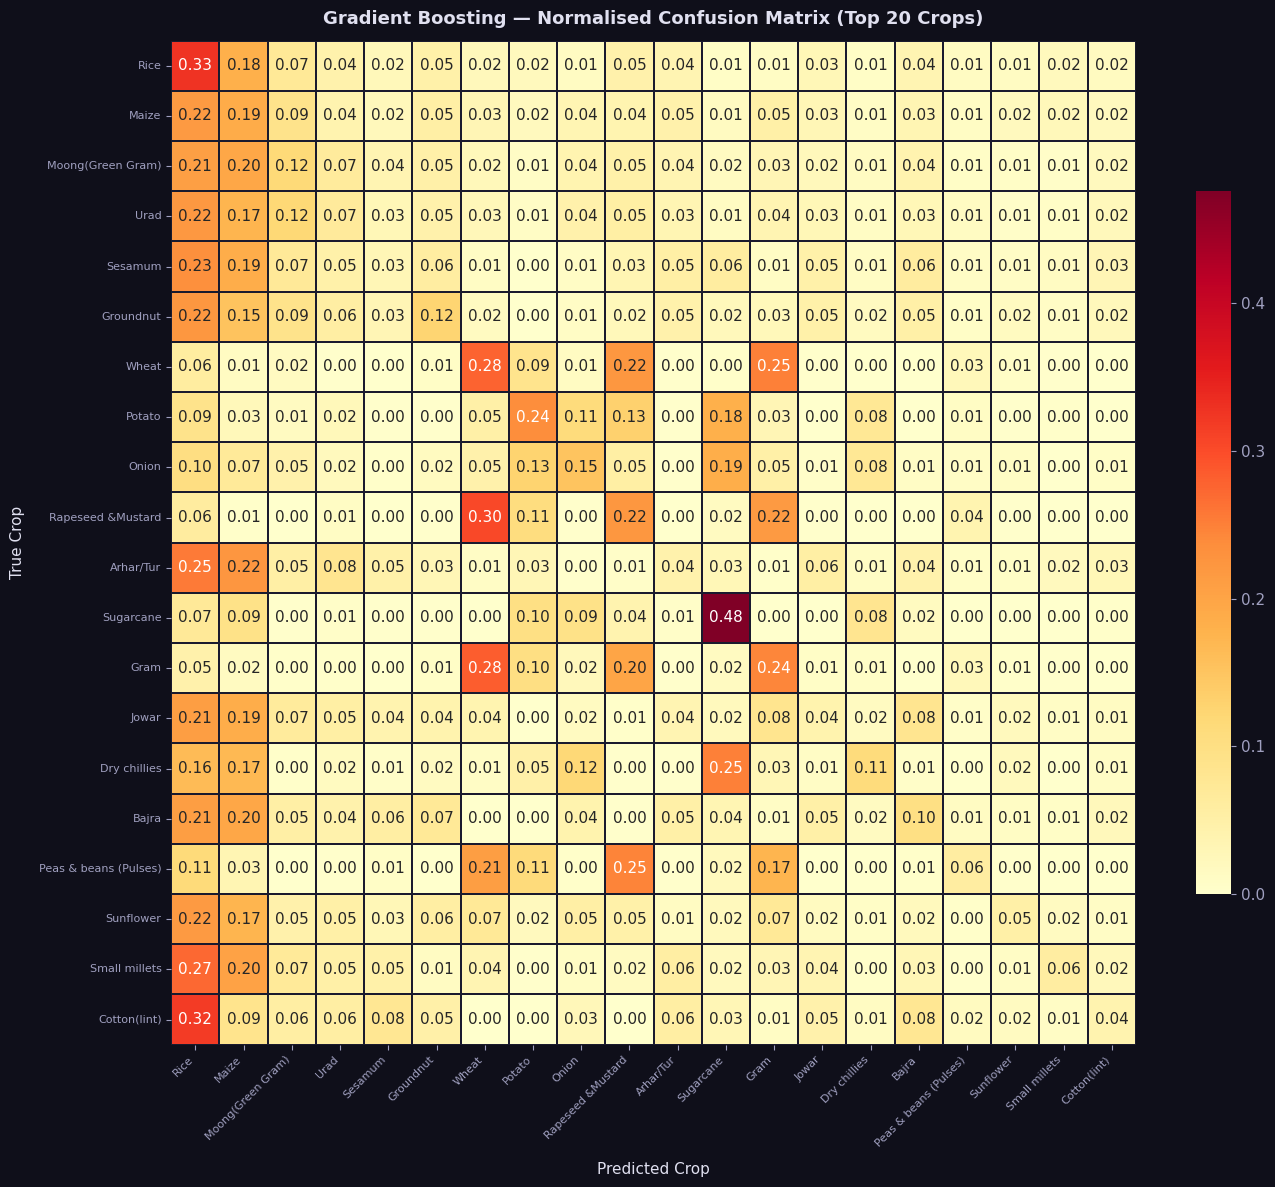

In [12]:
# Show confusion matrix for the 20 most frequent crops only
top20_crops = pd.Series(y_eval).value_counts().head(20).index.tolist()
mask_top20  = pd.Series(y_eval).isin(top20_crops).values

y_eval_top20 = np.array(y_eval)[mask_top20]
y_pred_top20 = np.array(y_pred)[mask_top20]

cm = confusion_matrix(y_eval_top20, y_pred_top20, labels=top20_crops, normalize='true')

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=top20_crops, yticklabels=top20_crops,
            linewidths=0.3, linecolor='#1a1a2e',
            cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_xlabel('Predicted Crop', labelpad=10)
ax.set_ylabel('True Crop', labelpad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_title(f'{best_name} — Normalised Confusion Matrix (Top 20 Crops)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 11. Feature Importance

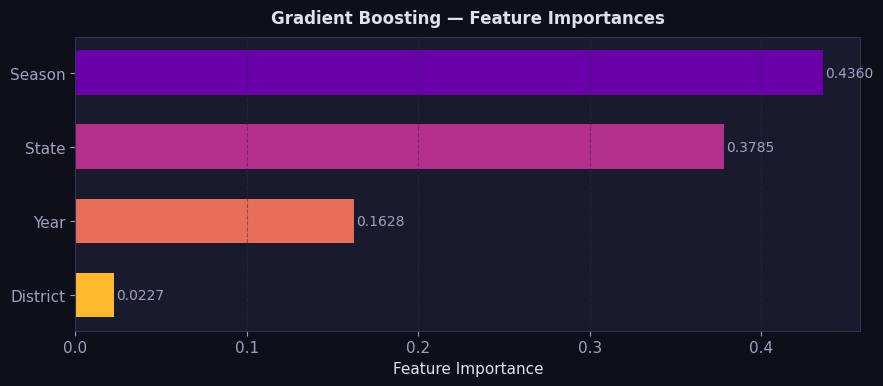

In [13]:
feature_names = CAT_FEATURES + NUM_FEATURES

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4))
    colors_fi = plt.cm.plasma(np.linspace(0.85, 0.2, len(fi_df)))
    ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color=colors_fi, edgecolor='none', height=0.6)
    for i, v in enumerate(fi_df['Importance'].values[::-1]):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10, color='#a0a0c0')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{best_name} — Feature Importances', fontsize=12, fontweight='bold', pad=10)
    ax.grid(axis='x')
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    # For Logistic Regression — mean absolute coefficient per feature
    coef_abs = np.abs(best_model.coef_).mean(axis=0)
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': coef_abs})
    fi_df = fi_df.sort_values('Importance', ascending=False)
    print('Mean absolute LR coefficient per feature:')
    print(fi_df.to_string(index=False))
else:
    print('Feature importance not available for this model type.')

## 12. Per-Class Accuracy — Top 30 Crops

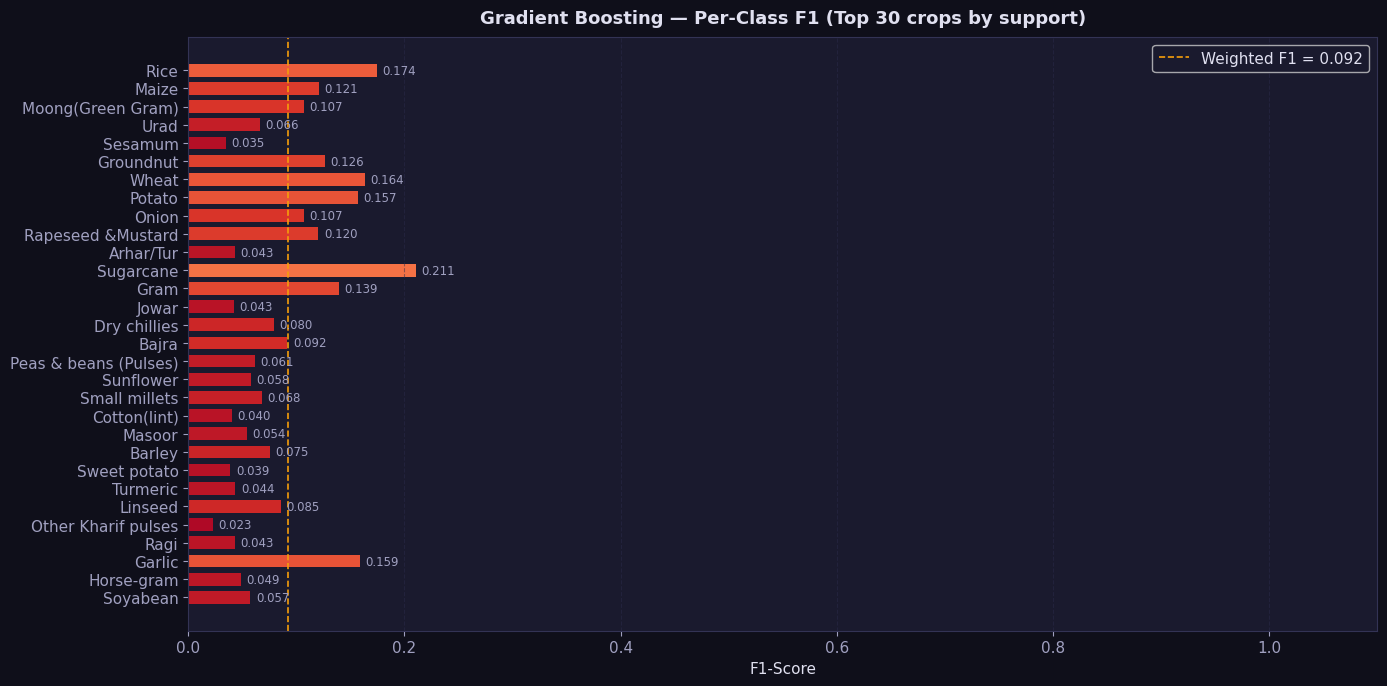

In [14]:
from sklearn.metrics import classification_report
report = classification_report(y_eval, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T

# Filter actual classes only (drop macro/weighted avg)
class_df = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
class_df = class_df.sort_values('support', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(14, 7))
colors_pc = plt.cm.RdYlGn(class_df['f1-score'].values)
bars = ax.barh(class_df.index[::-1], class_df['f1-score'].values[::-1],
               color=colors_pc[::-1], edgecolor='none', height=0.7)
for bar, val in zip(bars, class_df['f1-score'].values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5, color='#a0a0c0')
ax.set_xlabel('F1-Score')
ax.set_title(f'{best_name} — Per-Class F1 (Top 30 crops by support)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(0, 1.1)
ax.axvline(test_f1, color=HIGHLIGHT, linestyle='--', linewidth=1.2, label=f'Weighted F1 = {test_f1:.3f}')
ax.legend()
ax.grid(axis='x')
plt.tight_layout()
plt.show()

## 13. Model Comparison Radar Chart

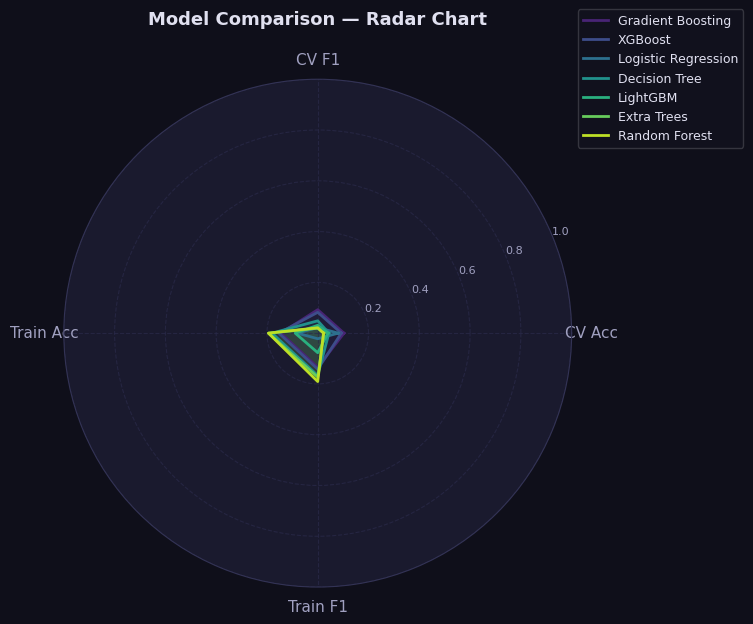

In [15]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

metrics_radar = ['CV Acc', 'CV F1', 'Train Acc', 'Train F1']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0f0f1a')

colors_r = plt.cm.viridis(np.linspace(0.1, 0.9, len(res_df)))

for i, (name, row) in enumerate(res_df.iterrows()):
    vals = [row['CV Acc'], row['CV F1'], row['Train Acc'], row['Train F1']]
    vals += vals[:1]
    ax.plot(angles, vals, color=colors_r[i], linewidth=2, label=name)
    ax.fill(angles, vals, color=colors_r[i], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=11, color='#e0e0f0')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8, color='#666688')
ax.tick_params(colors='#a0a0c0')
ax.grid(color='#2a2a4a', linestyle='--', alpha=0.7)
ax.set_title('Model Comparison — Radar Chart', pad=20, fontsize=13, fontweight='bold', color='#e0e0f0')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9,
          framealpha=0.2, labelcolor='#e0e0f0')
plt.tight_layout()
plt.show()

## 14. Save Summary

In [16]:
os.makedirs('../outputs', exist_ok=True)

summary = f"""
========================================================
  CROP RECOMMENDATION — MODEL SELECTION SUMMARY
========================================================
Task            : Multi-class Classification
Target          : Crop ({train['Crop'].nunique()} classes)
Features        : {FEATURES}
Train samples   : {len(train):,}
Test  samples   : {len(test):,}
CV Strategy     : StratifiedKFold (5 folds)
Encoding        : OrdinalEncoder (categorical)

--- CV Results (sorted by CV Accuracy) ---
{res_df[['CV Acc','CV Acc Std','CV F1','CV F1 Std','Overfit Gap','Time (s)']].to_string()}

--- Best Model ---
Name            : {best_name}
Test Accuracy   : {test_acc:.4f}
Test F1 (wtd)   : {test_f1:.4f}
Top-3 Accuracy  : {top3 if top3 else 'N/A'}
Overfit Gap     : {res_df.loc[best_name, 'Overfit Gap']:.4f}

--- Recommendation ---
Use {best_name} for crop recommendation.
Consider log-transforming Year if accuracy < 0.85.
========================================================
"""

out_path = '../outputs/crop_model_selection_summary.txt'
with open(out_path, 'w') as f:
    f.write(summary)

print(summary)
print(f'Summary saved → {os.path.abspath(out_path)}')


  CROP RECOMMENDATION — MODEL SELECTION SUMMARY
Task            : Multi-class Classification
Target          : Crop (55 classes)
Features        : ['State', 'District', 'Season', 'Year']
Train samples   : 276,261
Test  samples   : 69,066
CV Strategy     : StratifiedKFold (5 folds)
Encoding        : OrdinalEncoder (categorical)

--- CV Results (sorted by CV Accuracy) ---
                     CV Acc  CV Acc Std  CV F1  CV F1 Std  Overfit Gap  Time (s)
Gradient Boosting    0.1032      0.0012 0.0923     0.0013       0.0421 6944.5322
XGBoost              0.0930      0.0009 0.0820     0.0008       0.0604  714.5758
Logistic Regression  0.0804      0.0007 0.0221     0.0003       0.0000 1570.1240
Decision Tree        0.0440      0.0015 0.0486     0.0018       0.1362   19.6120
LightGBM             0.0405      0.0139 0.0310     0.0202       0.0482 1254.8158
Extra Trees          0.0243      0.0004 0.0194     0.0004       0.1697  116.9316
Random Forest        0.0226      0.0007 0.0211     0.0006  